In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "AntonV/mamba2-130m-hf"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float32)
model.eval()

/vol/fob-vol3/mi20/taquahie/Study_Project/chat_state_management/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] The fast path is not available because one of `(selective_state_update, causal_conv1d_fn, causal_conv1d_update)` is None. Falling back to the naive implementation. To install follow https://github.com/state-spaces/mamba/#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 218/218 [00:00<00:00, 6455.69it/s]


Mamba2ForCausalLM(
  (backbone): Mamba2Model(
    (embeddings): Embedding(50288, 768)
    (layers): ModuleList(
      (0-23): 24 x Mamba2Block(
        (norm): Mamba2RMSNorm()
        (mixer): Mamba2Mixer(
          (act): SiLUActivation()
          (conv1d): Conv1d(1792, 1792, kernel_size=(4,), stride=(1,), padding=(3,), groups=1792)
          (in_proj): Linear(in_features=768, out_features=3352, bias=False)
          (norm): MambaRMSNormGated()
          (out_proj): Linear(in_features=1536, out_features=768, bias=False)
        )
      )
    )
    (norm_f): Mamba2RMSNorm()
  )
  (lm_head): Linear(in_features=768, out_features=50288, bias=False)
)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(torch.__version__)
print(torch.version.cuda)

Using device: cuda
2.12.0+cu130
13.0


In [3]:
from datasets import load_dataset
dataset_name = "nvidia/Nemotron-RL-Instruction-Following-MultiTurnChat-v1"
split = "train"
dataset = load_dataset(dataset_name, split=split)

In [4]:
from src import model_loader, state_utils, evaluate as evaluate_module, data, autoencoder, plot, utils
model.to(device)

Mamba2ForCausalLM(
  (backbone): Mamba2Model(
    (embeddings): Embedding(50288, 768)
    (layers): ModuleList(
      (0-23): 24 x Mamba2Block(
        (norm): Mamba2RMSNorm()
        (mixer): Mamba2Mixer(
          (act): SiLUActivation()
          (conv1d): Conv1d(1792, 1792, kernel_size=(4,), stride=(1,), padding=(3,), groups=1792)
          (in_proj): Linear(in_features=768, out_features=3352, bias=False)
          (norm): MambaRMSNormGated()
          (out_proj): Linear(in_features=1536, out_features=768, bias=False)
        )
      )
    )
    (norm_f): Mamba2RMSNorm()
  )
  (lm_head): Linear(in_features=768, out_features=50288, bias=False)
)

In [5]:
sessions = data.extract_sessions(dataset)
states = []
list_of_snapshots = []
num_turn = 0
for session in sessions:
    snapshots = data.build_turn_snapshots(session)
    list_of_snapshots.append(snapshots)
    num_turn += len(snapshots)

print(len(list_of_snapshots), num_turn)

2011 30631


In [6]:
config = utils.read_config("configs/config1.yaml")
config["data"]["max_length"] = 1024

paths = config["paths"]
output_dir = paths["output_dir"]
text_history_dir = paths["text_history_dir"]+"/history.txt"
state_dir = paths["state_dir"]+"/state.pt"
plot_dir = paths["plot_dir"]
experiment2_path = output_dir + "/experiment2/experiment2.csv"
max_seq_length = config["data"]["max_length"]
experiment1_path = output_dir + "/experiment1/experiment1.csv"

In [7]:
import copy
import yaml
import torch
import pandas as pd
import csv
import time
import numpy as np
NUM_RUNS = 5

In [8]:
from transformers.models.mamba2 import modeling_mamba2
print([n for n in dir(modeling_mamba2) if 'ache' in n or 'Mamba' in n])

from transformers.models.mamba2 import modeling_mamba2
# Everything that's not a dunder
print([n for n in dir(modeling_mamba2) if not n.startswith('__')])


['Cache', 'DynamicCache', 'Mamba2Block', 'Mamba2CausalLMOutput', 'Mamba2Config', 'Mamba2ForCausalLM', 'Mamba2Mixer', 'Mamba2Model', 'Mamba2Output', 'Mamba2PreTrainedModel', 'Mamba2RMSNorm', 'MambaRMSNormGated', '__cached__']
['ACT2FN', 'Cache', 'DynamicCache', 'GenerationMixin', 'GradientCheckpointingLayer', 'Mamba2Block', 'Mamba2CausalLMOutput', 'Mamba2Config', 'Mamba2ForCausalLM', 'Mamba2Mixer', 'Mamba2Model', 'Mamba2Output', 'Mamba2PreTrainedModel', 'Mamba2RMSNorm', 'MambaRMSNormGated', 'ModelOutput', 'PreTrainedModel', 'apply_mask_to_padding_states', 'auto_docstring', 'causal_conv1d_fn', 'causal_conv1d_update', 'dataclass', 'init', 'is_fast_path_available', 'is_torchdynamo_compiling', 'lazy_load_kernel', 'logger', 'logging', 'mamba_chunk_scan_combined', 'mamba_split_conv1d_scan_combined', 'math', 'nn', 'pad_tensor_by_size', 'reshape_into_chunks', 'resolve_internal_import', 'segment_sum', 'selective_state_update', 'torch']


In [9]:
import src.mamba2_stateful as m

print(m.__file__)
print(dir(m)) 


/vol/fob-vol3/mi20/taquahie/Study_Project/chat_state_management/src/mamba2_stateful.py
['F', 'Mamba2Mixer', 'StatefulMamba2Mixer', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_seeded_conv1d', 'apply_mask_to_padding_states', 'debug_tensor', 'nn', 'pad_tensor_by_size', 'patch_model', 'reshape_into_chunks', 'run_forward_with_states', 'segment_sum', 'torch']


In [11]:
%load_ext autoreload
%autoreload 2

from src.mamba2_stateful import patch_model, run_forward_with_states

patch_model(model)
print("patched")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
patched


In [12]:
sessions = data.extract_sessions(dataset)
lengths = [len(s) for s in sessions]
import numpy as np
print(f"total sessions: {len(sessions)}")
print(f"min turns: {min(lengths)}")
print(f"max turns: {max(lengths)}")
print(f"mean turns: {np.mean(lengths):.1f}")
print(f"median turns: {np.median(lengths):.1f}")
print(f"turns >= 6: {sum(1 for l in lengths if l >= 6)}")
print(f"turns >= 10: {sum(1 for l in lengths if l >= 10)}")

total sessions: 2011
min turns: 9
max turns: 32
mean turns: 15.2
median turns: 14.0
turns >= 6: 2011
turns >= 10: 1634


In [13]:
from src import model_loader, state_utils, data, plot, utils
from src.evaluate import evaluate_baseline, evaluate_injected
from src.mamba2_stateful import patch_model

In [14]:
import torch

text = """
The capital of France is Paris.
Mamba is a state space model.
"""

inputs = tokenizer(text, return_tensors="pt").to(model.device)
input_ids = inputs["input_ids"]

print("Sequence length:", input_ids.shape[1])

with torch.no_grad():
    out_parallel = model(
        input_ids=input_ids,
        use_cache=False,
        return_dict=True,
    )

parallel_logits = out_parallel.logits

cache = None
token_logits = []

with torch.no_grad():

    for i in range(input_ids.shape[1]):

        token = input_ids[:, i:i+1]

        out = model(
            input_ids=token,
            cache_params=cache,
            use_cache=True,
            return_dict=True,
        )

        cache = out.cache_params
        token_logits.append(out.logits)

token_logits = torch.cat(token_logits, dim=1)

diff = (parallel_logits - token_logits).abs()

print("GLOBAL COMPARISON")
print("Shape identical :", parallel_logits.shape == token_logits.shape)
print("Allclose        :", torch.allclose(parallel_logits, token_logits))
print("Max diff        :", diff.max().item())
print("Mean diff       :", diff.mean().item())


print("\n==============================")
print("PER TOKEN")

for i in range(input_ids.shape[1]):

    d = (parallel_logits[:, i] - token_logits[:, i]).abs()

    print(
        f"Token {i:3d} | "
        f"max={d.max().item():.10f} | "
        f"mean={d.mean().item():.10f}"
    )




Sequence length: 18
GLOBAL COMPARISON
Shape identical : True
Allclose        : False
Max diff        : 0.0002593994140625
Mean diff       : 3.199466664227657e-05

PER TOKEN
Token   0 | max=0.0001296997 | mean=0.0000497332
Token   1 | max=0.0001602173 | mean=0.0000327849
Token   2 | max=0.0002136230 | mean=0.0000248084
Token   3 | max=0.0000667572 | mean=0.0000135632
Token   4 | max=0.0002059937 | mean=0.0000718243
Token   5 | max=0.0001831055 | mean=0.0000509098
Token   6 | max=0.0000953674 | mean=0.0000135137
Token   7 | max=0.0002174377 | mean=0.0000171583
Token   8 | max=0.0001678467 | mean=0.0000855124
Token   9 | max=0.0000915527 | mean=0.0000221102
Token  10 | max=0.0002593994 | mean=0.0000395342
Token  11 | max=0.0001296997 | mean=0.0000271336
Token  12 | max=0.0000762939 | mean=0.0000195735
Token  13 | max=0.0001754761 | mean=0.0000372516
Token  14 | max=0.0002059937 | mean=0.0000205333
Token  15 | max=0.0001220703 | mean=0.0000128265
Token  16 | max=0.0002212524 | mean=0.00002

In [ ]:
import torch
from tqdm import tqdm

text = "Hello world. " * 50000      # long enough text
low = 1
high = 32768                        # adjust if needed

device = model.device


def fits(seq_len):
    try:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        input_ids = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=seq_len,
        )["input_ids"].to(device)

        with torch.no_grad():
            _ = model(
                input_ids=input_ids,
                use_cache=False,
            )

        peak = torch.cuda.max_memory_allocated() / 1024**3

        del input_ids, _
        torch.cuda.empty_cache()

        return True, peak

    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        return False, None


best = 0
best_mem = 0

while low <= high:

    mid = (low + high) // 2

    ok, mem = fits(mid)

    if ok:
        best = mid
        best_mem = mem
        low = mid + 1
    else:
        high = mid - 1

print("=" * 60)
print(f"Maximum sequence length : {best}")
print(f"Peak GPU memory         : {best_mem:.2f} GB")
print("=" * 60)




Maximum sequence length : 7680
Peak GPU memory         : 35.50 GB


In [16]:
from datasets import load_dataset
torch.manual_seed(0)
dataset_name = "nvidia/Nemotron-RL-Instruction-Following-MultiTurnChat-v1"
split = "train"
dataset = load_dataset(dataset_name, split=split)

sessions = data.extract_sessions(dataset)
_, _, test_sessions = data.split_sessions(sessions, train=0.70, val=0.15, test=0.15)

Split: 1407 train / 301 val / 303 test  (seed=42)


In [17]:
lengths = []

for session in test_sessions:
    text = ""

    for turn in session:
        text += turn["content"]

    n_tokens = tokenizer(text, return_tensors="pt").input_ids.shape[1]
    lengths.append(n_tokens)

print("Max :", max(lengths))
print("Mean:", sum(lengths)/len(lengths))




Max : 35248
Mean: 6004.422442244225


In [18]:
import numpy as np 
print("50% :", np.percentile(lengths, 50)) 
print("75% :", np.percentile(lengths, 75)) 
print("90% :", np.percentile(lengths, 90)) 
print("95% :", np.percentile(lengths, 95)) 
print("99% :", np.percentile(lengths, 99)) 
print("Max :", max(lengths)) 



50% : 4094.0
75% : 8181.5
90% : 13217.4
95% : 18782.29999999998
99% : 30945.280000000035
Max : 35248


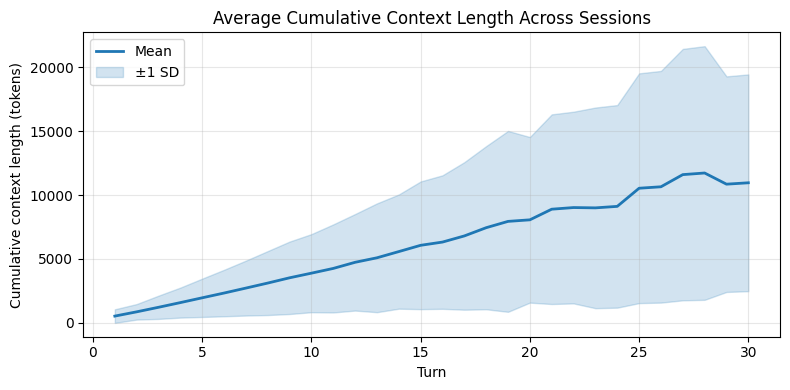

Turn  1: 513.7 ± 532.3 tokens (n=303)
Turn  2: 847.8 ± 608.9 tokens (n=303)
Turn  3: 1203.9 ± 911.5 tokens (n=303)
Turn  4: 1571.2 ± 1176.2 tokens (n=303)
Turn  5: 1947.2 ± 1502.4 tokens (n=303)
Turn  6: 2320.1 ± 1821.4 tokens (n=303)
Turn  7: 2708.8 ± 2152.2 tokens (n=303)
Turn  8: 3102.4 ± 2506.2 tokens (n=303)
Turn  9: 3514.9 ± 2838.4 tokens (n=303)
Turn 10: 3877.9 ± 3060.3 tokens (n=242)
Turn 11: 4249.6 ± 3451.0 tokens (n=230)
Turn 12: 4729.6 ± 3783.3 tokens (n=202)
Turn 13: 5082.7 ± 4263.5 tokens (n=187)
Turn 14: 5569.1 ± 4475.5 tokens (n=161)
Turn 15: 6061.3 ± 5003.6 tokens (n=142)
Turn 16: 6315.0 ± 5231.1 tokens (n=123)
Turn 17: 6796.0 ± 5782.0 tokens (n=105)
Turn 18: 7441.4 ± 6393.5 tokens (n=84)
Turn 19: 7936.1 ± 7087.7 tokens (n=71)
Turn 20: 8057.8 ± 6489.0 tokens (n=65)
Turn 21: 8891.2 ± 7431.7 tokens (n=54)
Turn 22: 9020.0 ± 7511.8 tokens (n=54)
Turn 23: 8995.4 ± 7862.0 tokens (n=41)
Turn 24: 9112.5 ± 7938.4 tokens (n=41)
Turn 25: 10533.9 ± 9003.3 tokens (n=30)
Turn 26: 106

In [24]:
import numpy as np
import matplotlib.pyplot as plt


turn_context_lengths = {}

for session in test_sessions:
    cumulative_tokens = 0

    for turn_idx, turn in enumerate(session):
        turn_tokens = len(
            tokenizer.encode(turn["content"], add_special_tokens=False)
        )

        cumulative_tokens += turn_tokens

        turn_context_lengths.setdefault(turn_idx + 1, []).append(cumulative_tokens)


num_sessions = len(test_sessions)
min_sessions = max(10, int(0.05 * num_sessions))

turns = []
means = []
stds = []
counts = []

for t in sorted(turn_context_lengths):
    values = np.array(turn_context_lengths[t])

    if len(values) >= min_sessions:
        turns.append(t)
        means.append(values.mean())
        stds.append(values.std(ddof=1))
        counts.append(len(values))

turns = np.array(turns)
means = np.array(means)
stds = np.array(stds)


plt.figure(figsize=(8, 4))

plt.plot(
    turns,
    means,
    color="tab:blue",
    linewidth=2,
    label="Mean"
)

plt.fill_between(
    turns,
    means - stds,
    means + stds,
    color="tab:blue",
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Turn")
plt.ylabel("Cumulative context length (tokens)")
plt.title("Average Cumulative Context Length Across Sessions")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


for t, m, s, n in zip(turns, means, stds, counts):
    print(f"Turn {t:2d}: {m:.1f} ± {s:.1f} tokens (n={n})")


